# Resting-state fMRI connectivity notebook (structured)

This notebook loads parcel-wise rs-fMRI time series, computes functional connectivity (FC) and aggregates FC into **Yeo7 network-to-network matrices**

Key math used throughout:
- **Pearson correlation** between ROI time series → FC matrix $R$
- **Fisher z-transform** $z=\operatorname{arctanh}(r)$ for averaging correlations
- **Network aggregation** = mean of FC values within/between Yeo7 communities

In [1]:
import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pickle
import networkx as nx

plt.style.use("seaborn-v0_8")
plt.rcParams['axes.grid'] = False

## 1) Setup and data discovery

We import packages and locate the pickled time-series files on disk.

In [2]:
DATA_DIR = "../../../Data/"   

print("Files found:")
print(glob.glob(os.path.join(DATA_DIR, "*.pkl")))

Files found:
['../../../Data\\rsfMRI_utils.pkl']


In [3]:
with open("../../../Data/rsfMRI_utils.pkl", "rb") as f:
    rsfMRI_utils = pickle.load(f)

print(rsfMRI_utils.keys())
yeo_info = rsfMRI_utils["yeo7"][200]
yeo_info

dict_keys(['AudROI', 'AudROIoverlap', 'FDindices', 'PCidx', 'yeo7'])


{'yeoOrder': array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
        113, 114, 115,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
         25,  26,  27,  28,  29,  30, 116, 117, 118, 119, 120, 121, 122,
        123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134,  31,
         32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43, 135,
        136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147,  44,
         45,  46,  47,  48,  49,  50,  51,  52,  53,  54, 148, 149, 150,
        151, 152, 153, 154, 155, 156, 157, 158,  55,  56,  57,  58,  59,
         60, 159, 160, 161, 162, 163, 164,  61,  62,  63,  64,  65,  66,
         67,  68,  69,  70,  71,  72,  73, 165, 166, 167, 168, 169, 170,
        171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181,  74,  75,
         76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,
         89,  90,  91,  92,  93,  94,  

## 2) Load parcel time series (per subject, per session)

Each file contains a dictionary of sessions → time-series matrix $T\times N$ (timepoints × parcels).

In [4]:
data_all = {}

files = sorted(glob.glob(os.path.join(DATA_DIR, "*/rsfMRI/*_TC_Schaefer.pkl")))
if files:
    file = files[0]
    subj_id = os.path.basename(file).split("_")[0]
    with open(file, "rb") as f:
        data_all[subj_id] = pickle.load(f)

print(f"Loaded {len(data_all)} subject(s): {list(data_all.keys())}")

Loaded 1 subject(s): ['003GNV']


In [5]:
# Canonical session axis: always 15 sessions
sessions_all = [f"V{str(k).zfill(2)}_200" for k in range(1, 16)]
x15 = np.arange(1, 16)

print("Canonical sessions:", sessions_all)

Canonical sessions: ['V01_200', 'V02_200', 'V03_200', 'V04_200', 'V05_200', 'V06_200', 'V07_200', 'V08_200', 'V09_200', 'V10_200', 'V11_200', 'V12_200', 'V13_200', 'V14_200', 'V15_200']


In [6]:
# Look at first subject
first_subj = list(data_all.keys())[0]
print("Subject ID:", first_subj)

print("\nSessions available:")
print(data_all[first_subj].keys())


Subject ID: 003GNV

Sessions available:
dict_keys(['V01_100', 'V01_200', 'V01_400', 'V01_800', 'V03_100', 'V03_200', 'V03_400', 'V03_800', 'V04_100', 'V04_200', 'V04_400', 'V04_800', 'V05_100', 'V05_200', 'V05_400', 'V05_800', 'V06_100', 'V06_200', 'V06_400', 'V06_800', 'V07_100', 'V07_200', 'V07_400', 'V07_800', 'V08_100', 'V08_200', 'V08_400', 'V08_800', 'V09_100', 'V09_200', 'V09_400', 'V09_800', 'V10_100', 'V10_200', 'V10_400', 'V10_800', 'V11_100', 'V11_200', 'V11_400', 'V11_800', 'V12_100', 'V12_200', 'V12_400', 'V12_800', 'V13_100', 'V13_200', 'V13_400', 'V13_800', 'V14_100', 'V14_200', 'V14_400', 'V14_800', 'V15_100', 'V15_200', 'V15_400', 'V15_800'])


In [7]:
# Yeo7 canonical names
network_names = [
    "Visual",
    "Somatomotor",
    "Dorsal Attention",
    "Ventral Attention",
    "Limbic",
    "Frontoparietal",
    "Default Mode"
]

## 3) Compute functional connectivity (FC) for one subject/session

Main operation: **Pearson correlation across parcels**.

If $X\in\mathbb{R}^{T\times N}$ is the time series (columns are parcels), then FC is:
$$
R_{ij}=\mathrm{corr}(X_{:i}, X_{:j})
$$

In [8]:
example_session = list(data_all[first_subj].keys())[1]

ts = data_all[first_subj][example_session]

print("Shape of time series matrix:")
print(ts.shape)

fc = np.corrcoef(ts, rowvar=False)  # correlate columns (regions)

Shape of time series matrix:
(320, 219)


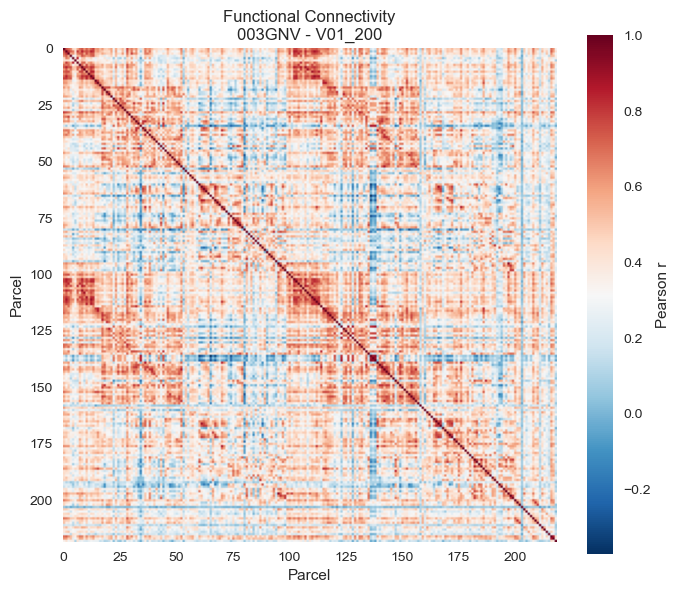

In [9]:
plt.figure(figsize=(7, 6))

plt.imshow(fc,
           cmap="RdBu_r")

plt.colorbar(label="Pearson r")
plt.title(f"Functional Connectivity\n{first_subj} - {example_session}")
plt.xlabel("Parcel")
plt.ylabel("Parcel")

plt.tight_layout()
plt.show()


## 4) Load Yeo7 network labels and reorder parcels

We load a Yeo7 label for each parcel and (optionally) sort parcels so the FC matrix is block-structured by network.

In [10]:
with open("../../../Data/rsfMRI_utils.pkl", "rb") as f:
    rsfMRI_utils = pickle.load(f)

print(rsfMRI_utils.keys())

dict_keys(['AudROI', 'AudROIoverlap', 'FDindices', 'PCidx', 'yeo7'])


In [11]:
yeo_info = rsfMRI_utils["yeo7"][200]

yeo_rois = np.array(yeo_info["yeoROIs"]).astype(int).ravel()
print("Yeo labels length:", len(yeo_rois))
print("Unique network ids:", np.unique(yeo_rois))

Yeo labels length: 219
Unique network ids: [1 2 3 4 5 6 7 8 9]


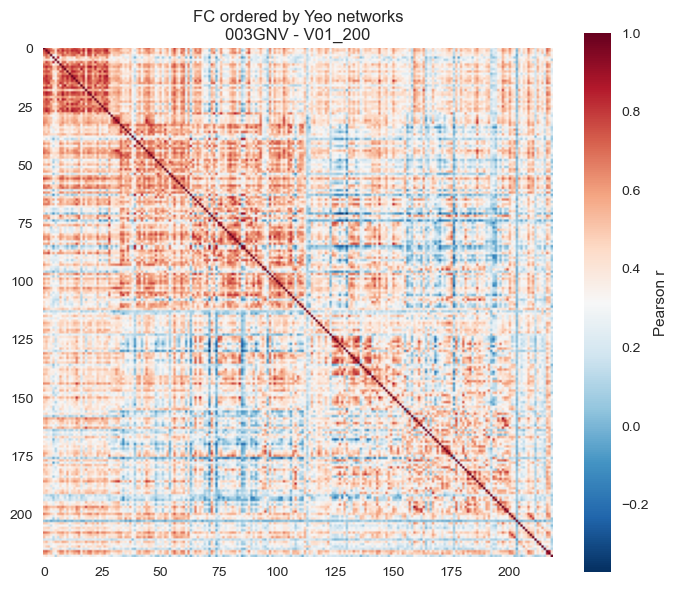

In [12]:
order = np.argsort(yeo_rois)

fc_sorted = fc[np.ix_(order, order)]
yeo_sorted = yeo_rois[order]

plt.figure(figsize=(7, 6))
plt.imshow(fc_sorted, cmap="RdBu_r")



plt.colorbar(label="Pearson r")
plt.title(f"FC ordered by Yeo networks\n{first_subj} - {example_session}")
plt.tight_layout()
plt.show()


## 5) Keep cortical parcels only (Yeo networks 1–7)

Here we drop label 8–9 (typically subcortical / non-cortical in this mapping) and keep only Yeo7 cortical parcels.

In [13]:
cortical_mask = yeo_rois <= 7   # keeps networks 1..7
print("Number of cortical ROIs:", cortical_mask.sum())

Number of cortical ROIs: 200


In [14]:
fc_cortical = fc[np.ix_(cortical_mask, cortical_mask)]
yeo_cortical = yeo_rois[cortical_mask]

print("Cortical FC shape:", fc_cortical.shape)

Cortical FC shape: (200, 200)


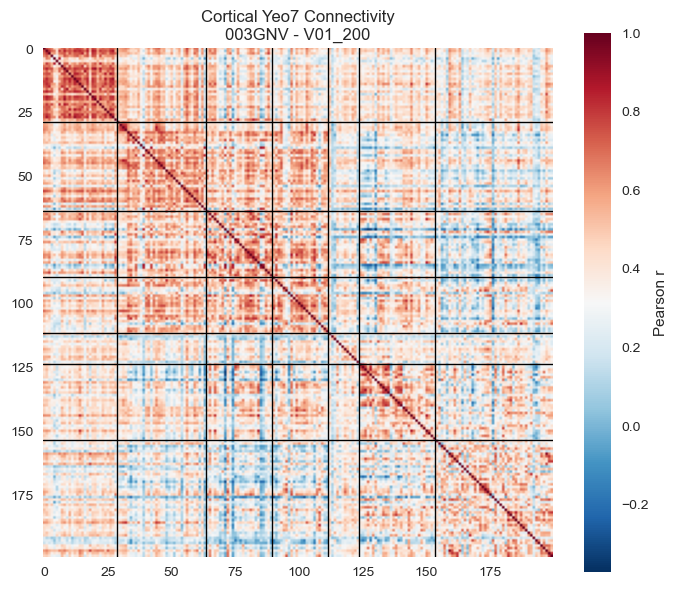

In [15]:
order = np.argsort(yeo_cortical)

fc_sorted = fc_cortical[np.ix_(order, order)]
yeo_sorted = yeo_cortical[order]

plt.figure(figsize=(7, 6))
plt.imshow(fc_sorted, cmap="RdBu_r")

# draw boundaries between networks
change = np.where(np.diff(yeo_sorted) != 0)[0] + 1
for b in change:
    plt.axhline(b - 0.5, color="black", linewidth=1)
    plt.axvline(b - 0.5, color="black", linewidth=1)

plt.colorbar(label="Pearson r")
plt.title(f"Cortical Yeo7 Connectivity\n{first_subj} - {example_session}")
plt.tight_layout()
plt.show()


## 6) Build a Yeo7 network-to-network connectivity matrix

Steps:
1. Compute parcel FC $R$
2. Keep cortical parcels → $R_{cx}$
3. Convert correlations to Fisher z: $Z=\operatorname{arctanh}(R_{cx})$
4. For each network pair (a,b), average $Z$ entries in that block
5. Convert back: $\bar r = \tanh(\bar z)$

Why Fisher z? It makes correlations more additive / closer to normal so averages are less biased.

In [16]:
# --- pick your subject/session ---
subj = first_subj          # or "008GNV"
sess = 'V01_200'         

# --- load labels (1..9) ---
yeo_info = rsfMRI_utils["yeo7"][200]
yeo_rois = np.array(yeo_info["yeoROIs"]).astype(int).ravel()

# --- compute FC ---
ts = data_all[subj][sess]                   # shape (T, 219)
fc = np.corrcoef(ts, rowvar=False)          # shape (219, 219)
np.fill_diagonal(fc, np.nan)                # ignore diagonal in averages

assert fc.shape[0] == len(yeo_rois), (fc.shape, len(yeo_rois))

# --- cortical-only mask: keep networks 1..7, drop 8 & 9 (subcortical) ---
cortical_mask = yeo_rois <= 7

fc_cx = fc[np.ix_(cortical_mask, cortical_mask)]
yeo_cx = yeo_rois[cortical_mask]

print("Cortical FC shape:", fc_cx.shape)
print("Unique cortical networks:", np.unique(yeo_cx))


Cortical FC shape: (200, 200)
Unique cortical networks: [1 2 3 4 5 6 7]


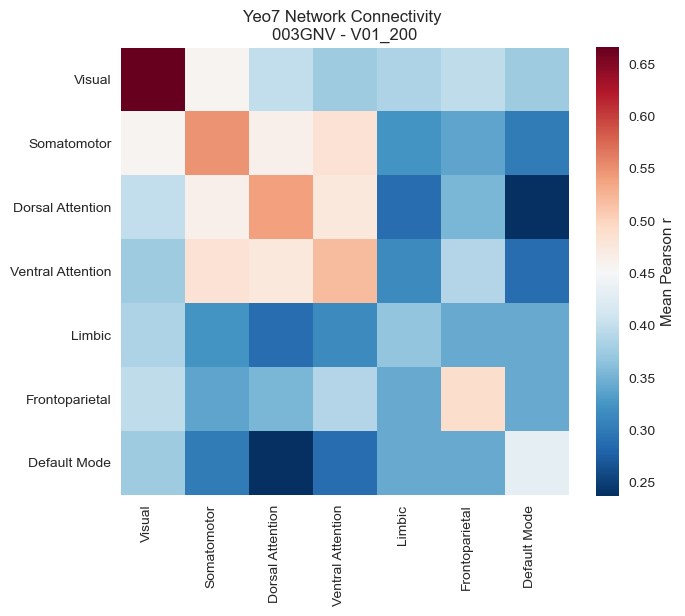

In [17]:
# Fisher transform first
fc_z = np.arctanh(fc_cx)

# Make sure diagonal is NaN
np.fill_diagonal(fc_z, np.nan)

nets = np.arange(1, 8)
netmat = np.full((7, 7), np.nan)

for i, ni in enumerate(nets):
    idx_i = np.where(yeo_cx == ni)[0]
    
    for j, nj in enumerate(nets):
        idx_j = np.where(yeo_cx == nj)[0]
        
        block = fc_z[np.ix_(idx_i, idx_j)]
        
        # If within-network, remove diagonal entries
        if i == j:
            block = block[~np.eye(len(idx_i), dtype=bool)]
        
        netmat[i, j] = np.nanmean(block)

# Convert back to r for interpretability
netmat_r = np.tanh(netmat)


plt.figure(figsize=(7, 6))
plt.imshow(netmat_r, cmap="RdBu_r")
plt.colorbar(label="Mean Pearson r")

plt.xticks(range(7), network_names, rotation=90, ha="right")
plt.yticks(range(7), network_names)

plt.title(f"Yeo7 Network Connectivity \n{subj} - {sess}")
plt.tight_layout()
plt.show()


## 7) Optional: Global signal regression (GSR) before FC

We regress out the global signal $g(t)=\frac{1}{N}\sum_i X_i(t)$ from each parcel:

$$
\beta_i = \frac{\langle g, X_i\rangle}{\langle g,g\rangle},\quad
X_i^{\mathrm{GSR}} = X_i - g\,\beta_i
$$

Then we recompute FC on the residuals.

In [18]:
ts = data_all[subj][sess].copy()

# regress out global signal (simple linear regression)
gs = np.nanmean(ts, axis=1)
gs = (gs - gs.mean()) / gs.std()

beta = (gs @ ts) / (gs @ gs)         # shape (n_rois,)
ts_gsr = ts - np.outer(gs, beta)

fc_gsr = np.corrcoef(ts_gsr, rowvar=False)
np.fill_diagonal(fc_gsr, np.nan)

# apply the same cortical mask you used before
fc_gsr_cx = fc_gsr[np.ix_(cortical_mask, cortical_mask)]
edges_gsr = fc_gsr_cx[np.triu_indices_from(fc_gsr_cx, k=1)]

# Fisher transform first
fc_z = np.arctanh(fc_gsr_cx)

# Make sure diagonal is NaN
np.fill_diagonal(fc_z, np.nan)

nets = np.arange(1, 8)
netmat = np.full((7, 7), np.nan)

for i, ni in enumerate(nets):
    idx_i = np.where(yeo_cx == ni)[0]
    
    for j, nj in enumerate(nets):
        idx_j = np.where(yeo_cx == nj)[0]
        
        block = fc_z[np.ix_(idx_i, idx_j)]
        
        # If within-network, remove diagonal entries
        if i == j:
            block = block[~np.eye(len(idx_i), dtype=bool)]
        
        netmat[i, j] = np.nanmean(block)

# Convert back to r for interpretability
netmat_r = np.tanh(netmat)



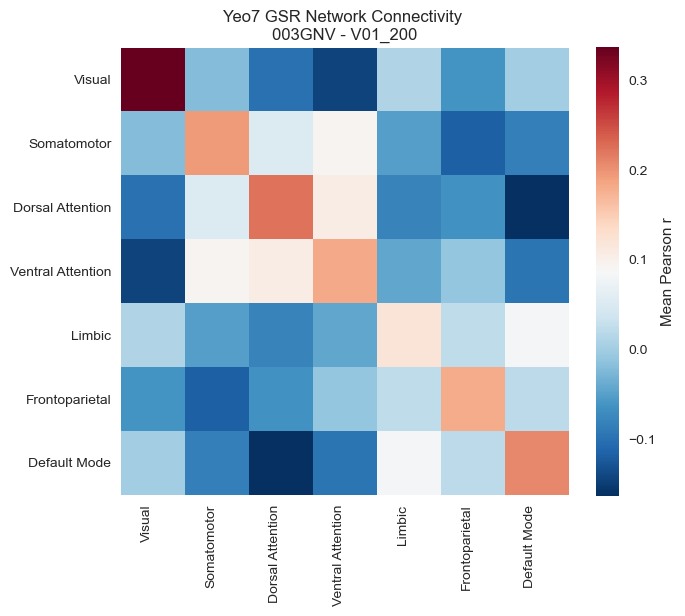

In [19]:
plt.figure(figsize=(7, 6))
plt.imshow(netmat_r, cmap="RdBu_r")
plt.colorbar(label="Mean Pearson r")

plt.xticks(range(7), network_names, rotation=90, ha="right")
plt.yticks(range(7), network_names)

plt.title(f"Yeo7 GSR Network Connectivity \n{subj} - {sess}")
plt.tight_layout()
plt.show()